In [41]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [76]:
mapped_reads_rg_diagnostics = pd.read_csv('mapped_reads_rg_diagnostics.txt', sep='\t')

In [77]:
mapped_reads_rg_diagnostics.loc[1]

readGroup                    JD206
totalReads                 2498736
passedQC                   2484087
duplicates                       0
avgReadLength              90.7281
seqCycles                      289
avgReadDist                1160.41
avgReadStart              0.000792
singleEnd                  2484087
pairedEnd                        0
properPairs                      0
avgFragmentLength                0
softClipped                 247601
avgSoftClippedLength       5.24061
avgUsableAlignedLength     85.4413
approximateDepth          0.067655
avgMappingQuality          42.8699
seqType                     single
Name: 1, dtype: object

In [8]:
mapped_reads_rg_filterSummary = pd.read_csv('mapped_reads_rg_filterSummary.txt', sep='\t')

In [9]:
mapped_reads_rg_filterSummary

,readGroup,No_read_group,Not_aligned,"MappedLengthOutside[0,500]",Duplicate,ImproperPair,Unmapped,FailedQC,SecondaryAlignment,SupplementaryAlignment
0,allReadGroups,0,0,0,0,0,0,0,0,14649
1,JD206,0,0,0,0,0,0,0,0,14649


In [74]:
alignedLengthHistogram = pd.read_csv('mapped_reads_rg_alignedLengthHistogram.txt', sep='\t')

In [75]:
alignedLengthHistogram

,readGroup,alignedLength,count
0,allReadGroups,30,17009
1,allReadGroups,31,13763
2,allReadGroups,32,11478
3,allReadGroups,33,10294
4,allReadGroups,34,9878
...,...,...,...
515,JD206,285,169
516,JD206,286,149
517,JD206,287,163
518,JD206,288,178


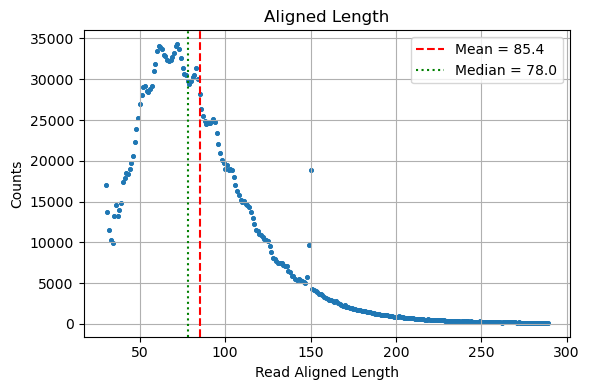

In [72]:

# Extract columns
x = alignedLengthHistogram['alignedLength']
y = alignedLengthHistogram['count']

# Compute statistics (weighted by count)
mean = np.average(x, weights=y)
median = x.repeat(y).median() if hasattr(x.repeat(y), 'median') else np.median(np.repeat(x, y))
#std = np.sqrt(np.average((x - mean) ** 2, weights=y))

# Plot
plt.figure(figsize=(6, 4))
plt.scatter(x, y, s=6)
plt.title('Aligned Length')
plt.xlabel('Read Aligned Length')
plt.ylabel('Counts')

# Add vertical lines for mean and median
plt.axvline(mean, color='red', linestyle='--', label=f'Mean = {mean:.1f}')
plt.axvline(median, color='green', linestyle=':', label=f'Median = {median:.1f}')
plt.legend()



plt.grid(True)
plt.tight_layout()
plt.show()


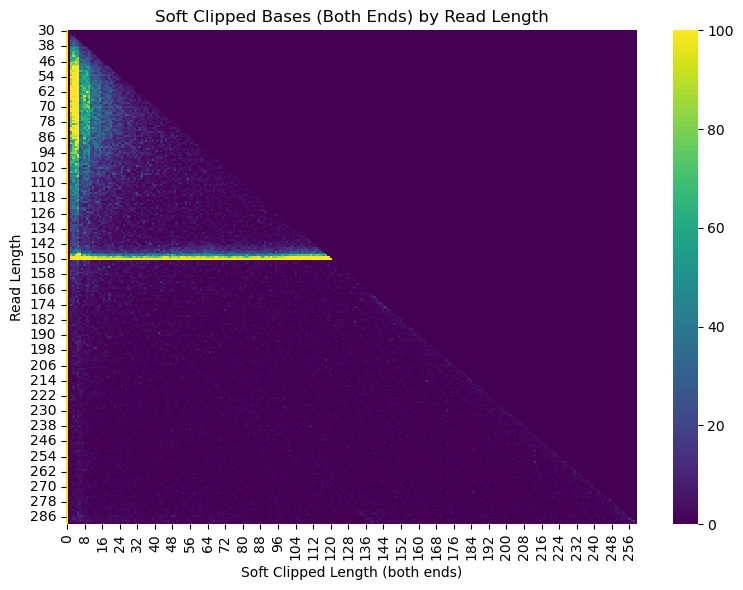

In [73]:
# Load the matrix
df = pd.read_csv('mapped_reads_rg_softClippingMatrixBoth.txt', sep='\t')

# Pivot into a matrix form: rows = readLength, cols = softClippedLengthBoth
pivot = df.pivot(index='readLength', columns='softClippedLengthBoth', values='counts').fillna(0)

# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(pivot, cmap='viridis',vmax=100)
plt.title('Soft Clipped Bases (Both Ends) by Read Length')
plt.xlabel('Soft Clipped Length (both ends)')
plt.ylabel('Read Length')
plt.tight_layout()
plt.show()

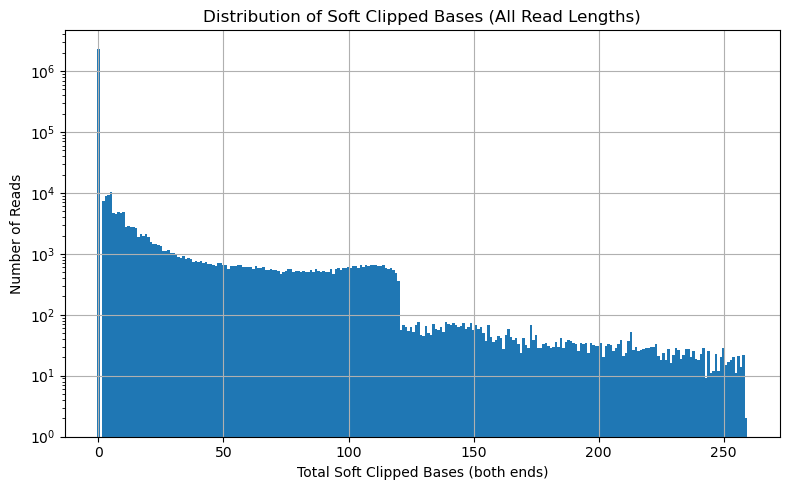

In [71]:
# Group by softClippedLengthBoth to get total reads per clipping amount
clip_distribution = df.groupby('softClippedLengthBoth')['counts'].sum()

# Plot
plt.figure(figsize=(8, 5))
plt.bar(clip_distribution.index, clip_distribution.values, width=1)
plt.xlabel('Total Soft Clipped Bases (both ends)')
plt.ylabel('Number of Reads')
plt.yscale("log")
plt.title('Distribution of Soft Clipped Bases (All Read Lengths)')
plt.grid(True)
plt.tight_layout()
plt.show()


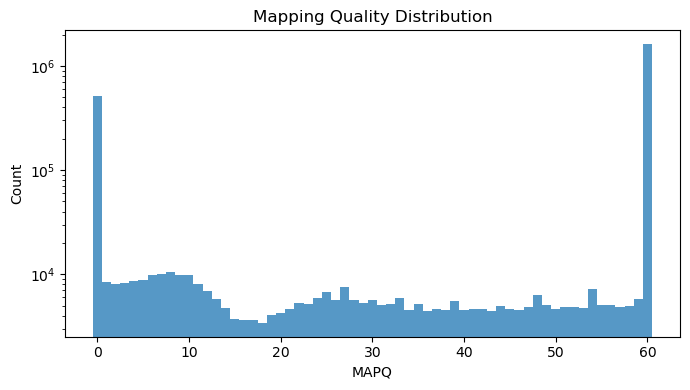

In [65]:

df = pd.read_csv("mapped_reads_rg_mappingQualityHistogram.txt", sep="\t")
plt.figure(figsize=(7,4))
plt.bar(df["mappingQuality"], df["count"], width=1, alpha = 0.5)
plt.title("Mapping Quality Distribution")
plt.xlabel("MAPQ")
plt.ylabel("Count")
plt.yscale("log")  # אופציונלי, כדי לראות גם ערכים קטנים
plt.tight_layout()
plt.show()